## Online Retail Data Cleaning and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the dataset
df = pd.read_csv('../data/raw/E-commerce_data.csv', encoding='ISO-8859-1')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# 2. Dataset inspection
print("Dataset Shape:", df.shape)
print("\n--- Data Summary ---")
df.info()

Dataset Shape: (541909, 8)

--- Data Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.2 MB


## 1. Initial Data Inspection

In [3]:
# 3. Viewing the first 5 rows of the dataset
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


#### Initial Data Quality Check

- Missing Values: `CustomerID` has 135,000 missing values, and `Description` has 1,454 missing values.
- Data Types: `InvoiceDate` is stored as text and needs to be converted to datetime. `CustomerID` is stored as `float64` because of the missing values.
- Data Issues: Need to check for negative quantities and zero or negative prices.

In [4]:
# 4. Checking for duplicates
df.duplicated().sum()

np.int64(5268)

In [5]:
# 5. Viewing the summary statistics of the dataset
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


## 2. Data Quality Assessment

In [6]:
# 6. Counting rows where Quantity is less than or equal to zero
condition = df['Quantity'] <= 0
filtered_df = df[condition]
row_count = len(filtered_df)
print("Count:", row_count)

Count: 10624


In [7]:
# 7. Counting rows where UnitPrice is less than or equal to zero
condition = df['UnitPrice'] <= 0
filtered_df = df[condition]
row_count = len(filtered_df)
print("Count:", row_count) 

Count: 2517


In [8]:
# 8. Lisiting unique values in the 'Country' column
df['Country'].unique()

<ArrowStringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

#### Standardizing Country Names

The `Country` column was cleaned by replacing country codes with their full names. Specifically, 'RSA' was changed to 'South Africa' and 'EIRE' was changed to 'Ireland'.

## 3. Data Cleaning

In [9]:
# 9. Replacing specific country codes with full country names
df['Country'] = df['Country'].replace({'RSA': 'South Africa', 'EIRE': 'Ireland'})

In [10]:
# 10. Checking the significance of 'Channel Islands', 'European Community', and 'Unspecified' in the 'Country' column.
df['Country'].value_counts()[['Channel Islands', 'European Community', 'Unspecified']]

Country
Channel Islands       758
European Community     61
Unspecified           446
Name: count, dtype: int64

In [11]:
# 11. Removing duplicate rows from the dataset and checking updated shape

df = df.drop_duplicates()
print("Updated shape:", df.shape)

Updated shape: (536641, 8)


In [12]:
# 12. Viewing updated unique values in the 'Country' column after replacement
df['Country'].unique()

<ArrowStringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
              'Ireland',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',         'South Africa']
Length: 38, dtype: str

#### Duplicate Removal
Removed duplicate rows to avoid counting the same transaction more than once.

In [13]:
# 13. Investigating negative values in the 'Quantity' column
df[df['Quantity'] < 0].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [14]:
# 14. Investigating negative values in the 'UnitPrice' column
df[df['UnitPrice'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/11 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/11 14:52,-11062.06,NaN,United Kingdom


In [15]:
# 15. Investigating zero values in the 'UnitPrice' column
df[df['UnitPrice'] == 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/10 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/10 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/10 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/10 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/10 14:34,0.0,NaN,United Kingdom


In [16]:
# 16. Investigating the count of zero values in the 'UnitPrice' column
(df['UnitPrice'] == 0).sum()

np.int64(2510)

#### Data Filtering

Removed rows with zero or negative quantities and prices to keep only valid sales transactions.

In [17]:
# 17. Filtering the dataset to include only rows where 'Quantity' and 'UnitPrice are greater than zero
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [18]:
# 18. Checking the updated shape of the dataset after filtering
print("Shape after filtering:", df.shape)

Shape after filtering: (524878, 8)


## 4. Final Data Quality Check

#### Missing Customer IDs

Kept rows with missing `CustomerID` values because they still contain valid sales and product information.

In [19]:
# 19. Checking for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64


In [20]:
# 20. Checking the 'InvoiceDate' column for its data type
print(df['InvoiceDate'].dtype)

str


#### Converting InvoiceDate to Datetime

Converted `InvoiceDate` from text to datetime format so it can be used for time-series analysis.

In [21]:
# 21. Converting 'InvoiceDate' to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

In [22]:
# 22. Verifying the conversion of 'InvoiceDate' to datetime format
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [23]:
# 23. Filtering the dataset to include only rows where 'Description' is not null
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


#### Missing Product Descriptions

Filtered the `Description` column for null values and then removed those rows.

In [24]:
# 24. Dropping rows where 'Description' is null
df = df.dropna(subset=['Description'])

#### Cleaning Summary
After reviewing and cleaning the dataset, I addressed missing values, duplicate records, invalid quantities and prices, date formatting, and inconsistent country names. The cleaned dataset is now ready for exploratory data analysis.

## 5. Exploratory Data Analysis

In [25]:
# 25. Creating a new column 'Revenue' by multiplying 'Quantity' and 'UnitPrice'
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [26]:
# 26. Viewing the summary statistics of the 'Revenue' column
df['Revenue'].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [27]:
#. 27. Identifying the top 5 products by total revenue
df.groupby('Description')['Revenue'].sum().nlargest(5)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
Name: Revenue, dtype: float64

In [28]:
# 28. Investigating Stock Codes that are not purely numeric
df[~df['StockCode'].str.match(r'^\d+$', na=False)]['StockCode'].value_counts()

StockCode
85123A    2253
85099B    2109
POST      1126
85099C     943
82494L     917
          ... 
84971l       1
85034b       1
85179a       1
90214U       1
47591b       1
Name: count, Length: 1054, dtype: int64

In [29]:
# 29. Verifying the details of the 'POST' StockCode
df[df['StockCode'] == 'POST'][['StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].head(20)

,StockCode,Description,Quantity,UnitPrice,Revenue
45,POST,POSTAGE,3,18.0,54.0
386,POST,POSTAGE,1,15.0,15.0
1123,POST,POSTAGE,1,18.0,18.0
5073,POST,POSTAGE,1,18.0,18.0
5258,POST,POSTAGE,1,18.0,18.0
5325,POST,POSTAGE,2,40.0,80.0
5369,POST,POSTAGE,3,18.0,54.0
6602,POST,POSTAGE,1,18.0,18.0
6676,POST,POSTAGE,2,18.0,36.0
6973,POST,POSTAGE,1,18.0,18.0


In [30]:
# 30. Filtering the dataset to include only rows where 'StockCode' contains only letters
df[df['StockCode'].str.match(r'^[A-Za-z]+$', na=False)][
    ['StockCode', 'Description']
].drop_duplicates().sort_values('StockCode')

,StockCode,Description
15017,AMAZONFEE,AMAZON FEE
299982,B,Adjust bad debt
84016,DCGSSBOY,BOYS PARTY BAG
84017,DCGSSGIRL,GIRLS PARTY BAG
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
157195,PADS,PADS TO MATCH ALL CUSHIONS
45,POST,POSTAGE
152709,S,SAMPLES
40383,m,Manual


#### Product Revenue Analysis
To identify the top-selling products, I needed to separate actual products from service fees. When I first checked revenue items, charges like postage showed up at the top. 

After checking the stock codes, I saw that some products contain letters (like `PADS`), so I cannot use a simple rule that removes all letters. Instead, I removed only confirmed fee and adjustment codes (`AMAZONFEE`, `B`, `DOT`, `M`, `POST`, `S`, `m`) into a separate `product_revenue` dataset. 

This lets me find the true highest physical items while keeping our main dataset `df` intact for forecasting overall weekly store sales.

In [31]:
# 31. Remove fee and postage codes to create a clean product dataset
admin_codes = ['AMAZONFEE', 'B', 'DOT', 'M', 'POST', 'S', 'm']
product_revenue = df[~df['StockCode'].isin(admin_codes)].copy()

In [32]:
# 32. Show the top 5 highest selling products by total revenue
top_5_products = product_revenue.groupby('Description')['Revenue'].sum().nlargest(5)
print(top_5_products)

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
Name: Revenue, dtype: float64


#### Investigating higher value orders 

When checking the highest selling products and largest transactions, I noticed two outliers:
* A customer placing an order worth over £77,000 (Customer 12346.0)
* Another customer placing an order worth over £168,000 (Customer 16446.0)

Before treating these as real revenue, we need to inspect the unfiltered order history for both customers to see if these orders were actually kept or later cancelled.

In [34]:
# 33. Viewing the top 5 highest single transaction lines by revenue
product_revenue.nlargest(5, 'Revenue')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40


In [35]:
# 34. Investigating the purchasing history of the top customer (CustomerID 16446.0)
product_revenue[product_revenue['CustomerID'] == 16446.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom,1.65
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom,1.25
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60


In [36]:
# 35. Investigating transactions for the second largest outlier (CustomerID 12346.0)
product_revenue[product_revenue['CustomerID'] == 12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [37]:
# 36. Inspecting unfiltered transaction history for CustomerID 12346.0 from the raw data
raw_check = pd.read_csv('../data/raw/E-commerce_data.csv', encoding='ISO-8859-1')
raw_check[raw_check['CustomerID'] == 12346.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/11 10:01,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/11 10:17,1.04,12346.0,United Kingdom


In [38]:
# 37. Inspecting unfiltered transaction history for CustomerID 16446.0 from the raw data
raw_check[raw_check['CustomerID'] == 16446.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,5/18/11 9:52,1.65,16446.0,United Kingdom
194355,553573,22982,PANTRY PASTRY BRUSH,1,5/18/11 9:52,1.25,16446.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/11 9:15,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,12/9/11 9:27,2.08,16446.0,United Kingdom


In [39]:
# 38. Identifying customer and product pairs to find fully cancelled orders
grouped = raw_check.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().reset_index()
zero_net_orders = grouped[grouped['Quantity'] == 0]
zero_net_orders

,CustomerID,StockCode,Quantity
0,12346.0,23166,0
273,12352.0,M,0
634,12359.0,22839,0
999,12362.0,22941,0
1000,12362.0,22942,0
...,...,...,...
267228,18274.0,23243,0
267229,18274.0,23245,0
267230,18274.0,84509A,0
267231,18274.0,84988,0


#### Removing Fully Cancelled Purchases

My review of the raw data showed that both major sales were cancelled almost immediately after being placed:

* The £77,000 order was cancelled 16 minutes later.
* The £168,000 order was cancelled 12 minutes later.

When I previously removed return entries, the initial purchase rows stayed behind, making it look like real sales that never actually took place.

How I resolved this across the dataset:
* Found matched pairs: I identified customer and item combinations where total items bought and items cancelled completely balanced out to zero (1,503 pairs).
* Filtered out matching rows: I removed these cancelled purchases (1,516 total rows), creating `clean_product_revenue`.
* Verified results: Both large cancelled sales are now removed, leaving only legitimate purchases.

In [45]:
# 39. Removing fully cancelled orders from the product_revenue dataset
merged = product_revenue.merge(
    zero_net_orders[['CustomerID', 'StockCode']], 
    on=['CustomerID', 'StockCode'], 
    how='left', 
    indicator=True
)

clean_product_revenue = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

# Compare row counts
print(f"Original product_revenue rows: {len(product_revenue)}")
print(f"Cleaned product_revenue rows: {len(clean_product_revenue)}")
print(f"Rows removed: {len(product_revenue) - len(clean_product_revenue)}")

Original product_revenue rows: 522724
Cleaned product_revenue rows: 521208
Rows removed: 1516


In [47]:
# 40. Verifying that the two major cancelled outlier accounts were removed from clean_product_revenue
display(clean_product_revenue[clean_product_revenue['CustomerID'] == 16446.0])
display(clean_product_revenue[clean_product_revenue['CustomerID'] == 12346.0])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
187187,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom,1.65
187188,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom,1.25


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [48]:
# 41. Identifying the true top 5 products by total revenue after removing cancelled orders
top_5_products = clean_product_revenue.groupby('Description')['Revenue'].sum().nlargest(5)
print(top_5_products)

Description
REGENCY CAKESTAND 3 TIER              173627.64
WHITE HANGING HEART T-LIGHT HOLDER    106195.42
PARTY BUNTING                          99435.63
JUMBO BAG RED RETROSPOT                93974.01
RABBIT NIGHT LIGHT                     66857.55
Name: Revenue, dtype: float64


In [49]:
# 42. Inspecting summary statistics for the top-selling product
clean_product_revenue[clean_product_revenue['Description'] == 'REGENCY CAKESTAND 3 TIER'][['Quantity', 'Revenue']].describe()

,Quantity,Revenue
count,1996.000000,1996.000000
mean,6.916333,86.987796
std,14.933655,174.563876
min,1.000000,12.720000
25%,1.000000,24.960000
50%,2.000000,25.500000
75%,6.000000,76.500000
max,272.000000,2978.400000


In [50]:
# 43. Aggregating cleaned sales into weekly revenue
weekly_revenue = clean_product_revenue.groupby(pd.Grouper(key='InvoiceDate', freq='W-SUN'))['Revenue'].sum().reset_index()
weekly_revenue

,InvoiceDate,Revenue
0,2010-12-05,180384.870
1,2010-12-12,299903.650
2,2010-12-19,206093.420
3,2010-12-26,85359.480
4,2011-01-02,0.000
5,2011-01-09,128343.350
6,2011-01-16,186504.780
7,2011-01-23,131998.110
8,2011-01-30,120418.710
9,2011-02-06,120677.350


#### Historical Revenue Trends
Visualizing weekly revenue over the 54-week period to identify trends, patterns, and unusual changes.

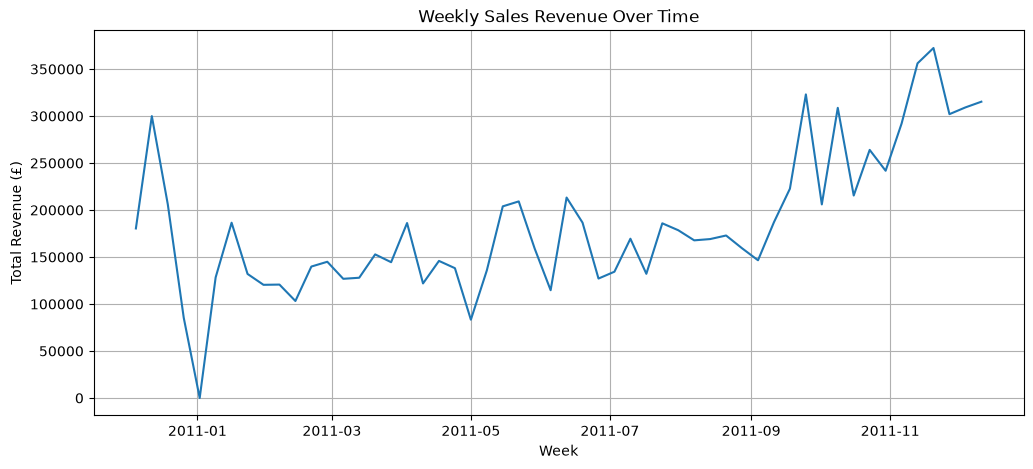

In [54]:
# 44. Visualizing the weekly sales revenue trend over time
plt.figure(figsize=(12, 5))
plt.plot(weekly_revenue['InvoiceDate'], weekly_revenue['Revenue'])
plt.title('Weekly Sales Revenue Over Time')
plt.xlabel('Week')
plt.ylabel('Total Revenue (£)')
plt.grid(True)
plt.show()

#### Weekly Revenue Distribution and Outliers
Examining weekly revenue to understand its distribution, variability, and unusual values.

In [61]:
# 45. Summary statistics for weekly revenue
weekly_revenue['Revenue'].describe()

count        54.000000
mean     184372.483407
std       75233.174707
min           0.000000
25%      132693.852500
50%      169289.850000
75%      212250.370000
max      372402.210000
Name: Revenue, dtype: float64

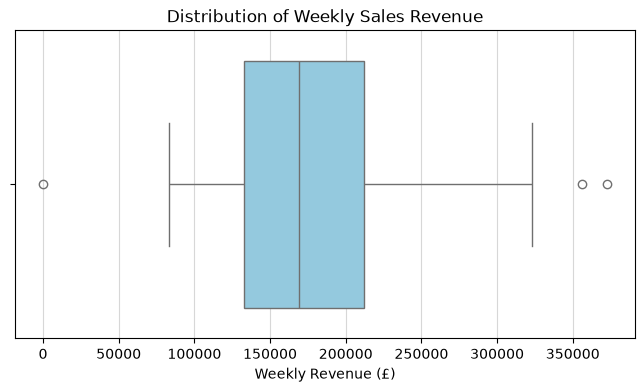

In [62]:
# 46. Visualizing the distribution of weekly revenue with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=weekly_revenue['Revenue'], color='skyblue')

plt.title('Distribution of Weekly Sales Revenue')
plt.xlabel('Weekly Revenue (£)')
plt.grid(axis='x', alpha=0.5)
plt.show()

#### Previous Week's Revenue as a Predictor
Examining whether the previous week's revenue can help predict the next week's revenue.

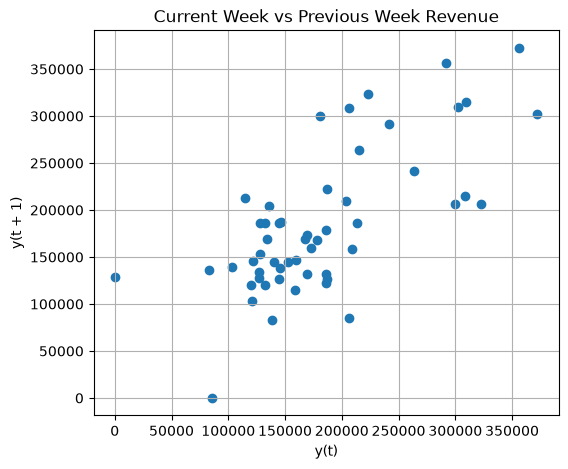

In [63]:
# 47. Lag plot of weekly revenue
from pandas.plotting import lag_plot

plt.figure(figsize=(6, 5))
lag_plot(weekly_revenue['Revenue'])

plt.title('Current Week vs Previous Week Revenue')
plt.grid(True)
plt.show()

#### Top Revenue-Generating Products
Identifying which products contribute the most to total business revenue.

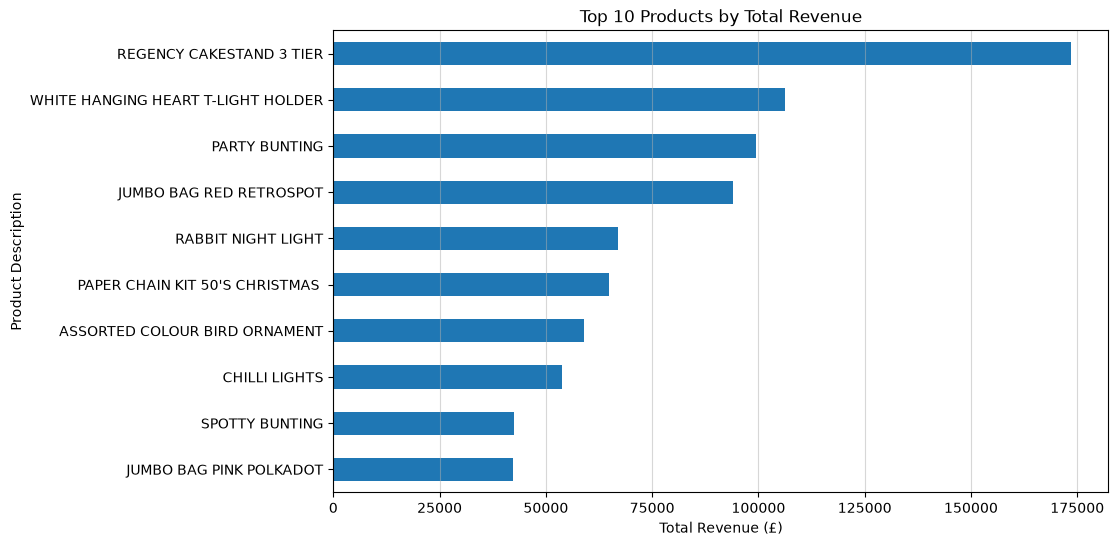

In [64]:
# 48. Top 10 products by total revenue
top_products = clean_product_revenue.groupby('Description')['Revenue'].sum()
top_products = top_products.sort_values(ascending=False).head(10)

# Plotting the top 10 products
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product Description')
plt.grid(axis='x', alpha=0.5)
plt.show()

## Summary of EDA Findings

1. Seasonality & Trend: Weekly sales remain steady for most of the year, then increase sharply toward the end of the year, reaching over £370k.

2. Revenue Distribution: Weekly revenue is moderately right-skewed, with a mean of £184k and a median of £169k.

3. Previous Week's Revenue: The Lag-1 plot shows a positive relationship between the previous week's revenue and the current week's revenue, supporting its use as a baseline for forecasting.

4. Top Products: Home décor and event-related products generate a large portion of revenue, with `REGENCY CAKESTAND 3 TIER` generating over £170k.

5. Data Preparation:

   * The week of `2011-01-02` has £0 in revenue because of the holiday closure and may need to be addressed before modeling.
   * The final week, `2011-12-11`, only contains 5 days of data, so it should be removed before splitting the data into training and testing sets.
